# 08. yfinance 실시간 검색 — 실험 1 모델 적용

최종 채택된 실험 1(실험 1, MinMaxScaler) 모델로 yfinance에서 임의의 미국 주식 패턴을 실시간 검색하는 노트북이다. 전처리(MinMaxScaler + 대비 1.5배)를 노트북 01과 완전히 동일하게 적용해 학습 환경과 추론 환경의 일관성을 보장한다.

## 핵심 설계 원칙

| 항목 | 구현 내용 |
|------|-----------|
| 종목 범위 | yfinance로 모든 미국 주식/지수 지원 |
| 전처리 | MinMaxScaler per window + mplfinance + 대비 1.5배 (노트북 01 동일) |
| 거래소 검증 | NMS, NYSE, NYSEARCA, NYSEMKT, NYQ, NGM만 허용 |
| 쿼리 본인 제외 | 같은 종목 + 2주 이내 패턴은 자동 제외 |
| 검색 기준 | 사용자 입력 날짜 직전 12주 주봉 데이터 |

## 처리 흐름

1. 종목 코드 + 기준 날짜 입력
2. yfinance에서 직전 12주 주봉 OHLC 다운로드
3. MinMaxScaler 정규화 후 mplfinance 캔들스틱 이미지 생성 (224×224, 대비 1.5배)
4. ResNet18 모델로 512차원 임베딩 추출
5. 전체 47,923개 패턴 데이터베이스와 L2 거리 계산
6. Top-100 후보에서 본인·중복 종목 제외 → Top-3 반환
7. 5×3 행렬 형식으로 컬러 캔들스틱 시각화

## 1. 라이브러리 설치 및 임포트

mplfinance와 yfinance를 설치하고 필요한 라이브러리를 불러온다. Colab 환경에서 한글 폰트(NanumGothic)를 설정해 차트 제목이 깨지지 않도록 한다.

In [1]:
# mplfinance, yfinance 설치
!pip install -q mplfinance yfinance

import numpy as np
import pandas as pd
import os
import gc
import warnings
from tqdm import tqdm

# 이미지 처리
from PIL import Image, ImageEnhance
import cv2

# PyTorch
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import models

# 시각화
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.gridspec import GridSpec
from matplotlib import font_manager, rc
import platform
import mplfinance as mpf
import io

# yfinance
import yfinance as yf
from datetime import datetime, timedelta

# sklearn
from sklearn.preprocessing import MinMaxScaler

# Google Colab
from google.colab import drive

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

# 한글 폰트 설정 (Colab)
if platform.system() == 'Linux':
    !apt-get -qq -y install fonts-nanum > /dev/null
    font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
    font_manager.fontManager.addfont(font_path)
    rc('font', family='NanumGothic')
    plt.rcParams['axes.unicode_minus'] = False
    print("✅ 한글 폰트 설정 완료 (NanumGothic)")

print("✅ 라이브러리 임포트 완료")
print(f"✅ PyTorch: {torch.__version__}")
print(f"✅ CUDA: {torch.cuda.is_available()}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.0/75.0 kB 3.5 MB/s eta 0:00:00
✅ 한글 폰트 설정 완료 (NanumGothic)
✅ 라이브러리 임포트 완료
✅ PyTorch: 2.8.0+cu126
✅ CUDA: True


## 2. 경로 설정 및 데이터 준비

Google Drive를 마운트하고 실험 1 모델 경로와 이미지 디렉터리를 설정한다. 컬러 캔들스틱 생성에 필요한 원본 OHLC CSV도 로컬로 복사한다.

In [2]:
# Google Drive 마운트
drive.mount('/content/drive')

# 경로 설정 (실험 1만 사용)
GDRIVE_BASE = '/content/drive/MyDrive/Patron'
MODEL_PATH = f'{GDRIVE_BASE}/models/best_model.pth'
DATA_PATH = '/content/data'
IMAGE_DIR = f'{DATA_PATH}/images'

print("="*60)
print("📁 경로 설정 (실험 1)")
print("="*60)
print(f"모델: {MODEL_PATH}")
print(f"이미지: {IMAGE_DIR}")
print("="*60)

Mounted at /content/drive
📁 경로 설정 (실험 1)
모델: /content/drive/MyDrive/Patron/models/best_model.pth
이미지: /content/data/images


In [3]:
# 실험 1 데이터 준비 (로컬 스토리지 사용)
print("📦 실험 1 데이터 복사 중...")
!mkdir -p {DATA_PATH}
!cp {GDRIVE_BASE}/images.tar {DATA_PATH}/

print("📂 데이터 압축 해제 중...")
!tar -xf {DATA_PATH}/images.tar -C {DATA_PATH}/

# 메타데이터 복사
!cp {GDRIVE_BASE}/data/processed/metadata_all.csv {DATA_PATH}/metadata.csv

# raw 폴더 복사 (원본 OHLC 데이터) ⭐
print("\n📦 raw 폴더 복사 중 (원본 OHLC)...")
!mkdir -p {DATA_PATH}/raw
!cp -r {GDRIVE_BASE}/data/raw/* {DATA_PATH}/raw/

print("\n✅ 데이터 준비 완료!")
!echo "이미지 개수: $(ls {IMAGE_DIR} | wc -l)"
!echo "raw CSV 개수: $(ls {DATA_PATH}/raw | wc -l)"

📦 실험 1 데이터 복사 중...
📂 실험 1 압축 해제 중...

📦 raw 폴더 복사 중 (원본 OHLC)...

✅ 데이터 준비 완료!
이미지 개수: 49987
raw CSV 개수: 172


## 3. GPU 확인 및 모델 정의

GPU를 확인하고 `ChartEmbeddingModel` 클래스를 정의한다. 1채널 ResNet18 백본에 L2 정규화 512차원 임베딩을 출력하는 구조로, 모든 patron 모델이 공유한다. 추론 시 `pretrained=False`로 초기화 후 체크포인트를 로드한다.

In [4]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"🔥 디바이스: {device}")

if torch.cuda.is_available():
    print(f"✅ GPU: {torch.cuda.get_device_name(0)}")
    torch.cuda.empty_cache()
    gc.collect()

🔥 디바이스: cuda
✅ GPU: NVIDIA A100-SXM4-40GB


In [5]:
class ChartEmbeddingModel(nn.Module):
    def __init__(self, embedding_dim=512):
        super(ChartEmbeddingModel, self).__init__()
        resnet = models.resnet18(pretrained=False)
        resnet.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)
        self.features = nn.Sequential(*list(resnet.children())[:-1])
        self.embedding_dim = embedding_dim

    def forward(self, x):
        features = self.features(x)
        embeddings = features.view(features.size(0), -1)
        embeddings = F.normalize(embeddings, p=2, dim=1)
        return embeddings

print("✅ 모델 클래스 정의 완료")

✅ 모델 클래스 정의 완료


## 4. 모델 로드

실험 1 Best 체크포인트(Val Loss 0.005174, Epoch 1)를 불러와 eval 모드로 설정한다. 이 모델이 MinMaxScaler 정규화로 학습됐기 때문에, 추론 시도 동일한 MinMaxScaler 정규화를 적용해야 한다.

In [6]:
# 실험 1 모델 로드
print("📥 실험 1 모델 로드 중...")
model = ChartEmbeddingModel(embedding_dim=512).to(device)
checkpoint = torch.load(MODEL_PATH, map_location=device)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()
print(f"✅ 실험 1 로드 완료 (Epoch {checkpoint['epoch']}, Val Loss: {checkpoint['val_loss']:.6f})")

print("\n" + "="*60)
print("🎉 모델 로드 완료!")
print("="*60)

📥 실험 1 모델 로드 중...
✅ 실험 1 로드 완료 (Epoch 1, Val Loss: 0.005174)

🎉 모델 로드 완료!


## 5. 메타데이터 로드

메타데이터 CSV를 불러오고 3개월 수익률이 없는 행을 제거한다. 인덱스를 리셋해 이후 임베딩 배열과 메타데이터 행의 1:1 매핑이 정확하게 이루어지도록 한다.

In [7]:
# 메타데이터 로드
metadata = pd.read_csv(f'{DATA_PATH}/metadata.csv')
metadata = metadata.dropna(subset=['return_3m'])

# 인덱스 리셋 (중요!)
metadata = metadata.reset_index(drop=True)

print("📊 메타데이터 로드 완료")
print(f"총 패턴: {len(metadata):,}개")
print(f"종목 수: {metadata['ticker'].nunique()}개")
print(f"\n✅ 컬럼: {list(metadata.columns)}")
print(f"✅ 인덱스 범위: {metadata.index.min()} ~ {metadata.index.max()}")

📊 메타데이터 로드 완료
총 패턴: 47,923개
종목 수: 172개

✅ 컬럼: ['ticker', 'pattern_id', 'start_date', 'end_date', 'start_price', 'end_price', 'sector', 'industry', 'return_3m', 'return_6m', 'return_1y']
✅ 인덱스 범위: 0 ~ 47922


## 6. 전체 임베딩 생성 (데이터베이스 구축)

47,923개 패턴 전체를 모델에 통과시켜 (47,923×512) 임베딩 행렬을 생성한다. 이 행렬이 검색 데이터베이스가 되며, 이후 L2 거리 계산 시 numpy 벡터 연산으로 빠르게 처리한다. 약 3분 소요.

In [8]:
print("🚀 전체 임베딩 생성 시작!")
print("="*60)

embeddings_list = []

with torch.no_grad():
    for idx in tqdm(metadata.index, desc="임베딩 생성", leave=True):
        ticker = metadata.loc[idx, 'ticker']
        pattern_id = metadata.loc[idx, 'pattern_id']
        img_path = f"{IMAGE_DIR}/{ticker}_{pattern_id}.npy"

        try:
            img = np.load(img_path)
            img_tensor = torch.FloatTensor(img).unsqueeze(0).unsqueeze(0).to(device) / 255.0
            embedding = model(img_tensor).squeeze(0).cpu().numpy()
            embeddings_list.append(embedding)
        except:
            embeddings_list.append(np.zeros(512, dtype=np.float32))

embeddings = np.vstack(embeddings_list).astype('float32')
print(f"✅ 임베딩 생성 완료: {embeddings.shape}")

# 메모리 정리
torch.cuda.empty_cache()
gc.collect()

print("\n" + "="*60)
print("🎉 전체 임베딩 생성 완료!")
print(f"📊 Shape: {embeddings.shape}")
print("="*60)

🚀 전체 임베딩 생성 시작!


실험 1 임베딩 생성: 100%|██████████| 47923/47923 [02:40<00:00, 298.50it/s]


✅ 임베딩 생성 완료: (47923, 512)

🎉 전체 임베딩 생성 완료!
📊 Shape: (47923, 512)


## 7. 쿼리 이미지 생성 함수 (노트북 01 전처리 방식)

OHLC numpy 배열을 mplfinance로 캔들스틱 이미지로 변환하고 대비를 1.5배 높인다. 노트북 01 전처리와 완전히 동일한 방식(흑백 캔들, 검은 배경, LANCZOS 리사이즈, Contrast 1.5x)으로 224×224 그레이스케일 이미지를 생성한다. 이 일관성이 추론 품질을 보장한다.

In [22]:
def ohlc_to_grayscale_image(ohlc_array, temp_path='/content/temp_chart.png'):
    """
    (12, 4) OHLC numpy 배열 → (224, 224) 그레이스케일 numpy 배열
    노트북 01 전처리와 100% 동일한 방식

    Args:
        ohlc_array: (12, 4) numpy 배열 (Open, High, Low, Close)
        temp_path: 임시 PNG 파일 경로

    Returns:
        img_array: (224, 224) grayscale numpy 배열
    """
    try:
        # DataFrame 생성
        df = pd.DataFrame(ohlc_array, columns=['Open', 'High', 'Low', 'Close'])
        df.index = pd.date_range('2020-01-01', periods=len(df), freq='W')

        # mplfinance 스타일 (노트북 01과 동일)
        mc = mpf.make_marketcolors(
            up='white', down='white',
            edge='white', wick='white',
            volume='white'
        )

        s = mpf.make_mpf_style(
            marketcolors=mc,
            gridstyle='',
            y_on_right=False,
            facecolor='black',
            figcolor='black'
        )

        # 임시 PNG 저장
        mpf.plot(
            df, type='candle', style=s,
            savefig=temp_path,
            figsize=(2.24, 2.24),
            axisoff=True,
            closefig=True
        )

        # PNG → 그레이스케일 → 대비 1.5배 (노트북 01과 동일)
        img = Image.open(temp_path).convert('L')
        img_resized = img.resize((224, 224), Image.LANCZOS)
        enhancer = ImageEnhance.Contrast(img_resized)
        img_enhanced = enhancer.enhance(1.5)  # 대비 1.5배

        img_array = np.array(img_enhanced, dtype=np.uint8)

        # 메모리 해제
        img.close()
        img_resized.close()
        del img, img_resized, img_enhanced, enhancer, df

        # 임시 파일 삭제
        if os.path.exists(temp_path):
            os.remove(temp_path)

        return img_array

    except Exception as e:
        print(f"⚠️ 이미지 생성 실패: {e}")
        return None

print("✅ 이미지 생성 함수 정의 완료 (노트북 01 전처리 방식)")

✅ 이미지 생성 함수 정의 완료 (노트북 01 방식)


## 8. 미국 거래소 검증 함수

yfinance에서 종목 정보를 받아 미국 거래소(NMS, NYSE 등) 여부를 확인한다. 비미국 주식이나 OTC 종목을 사전에 걸러내 검색 범위를 유효한 종목으로 제한한다. 모델이 미국 주식 패턴으로 학습됐기 때문에 이 검증이 검색 품질에 직접 영향을 미친다.

In [64]:
# 미국 거래소 리스트 (OTCMKTS 제외)
US_EXCHANGES = ['NMS', 'NYSE', 'NYSEARCA', 'NYSEMKT' , 'NYQ', 'NGM']

def validate_us_stock(ticker):
    """
    yfinance에서 미국 주식 여부 검증

    Args:
        ticker: 종목 코드 (예: 'NVDA', 'SPY')

    Returns:
        (is_valid, exchange): (True/False, 거래소명)
    """
    try:
        ticker_obj = yf.Ticker(ticker)
        info = ticker_obj.info

        # 주식 정보가 있는지 확인
        if not info or len(info) < 5:
            return False, "No Data"

        # 거래소 확인
        exchange = info.get('exchange', 'Unknown')

        if exchange in US_EXCHANGES:
            return True, exchange
        else:
            return False, exchange

    except Exception as e:
        return False, f"Error: {str(e)[:30]}"

print("✅ 미국 거래소 검증 함수 정의 완료")
print(f"✅ 허용 거래소: {US_EXCHANGES}")

✅ 미국 거래소 검증 함수 정의 완료
✅ 허용 거래소: ['NMS', 'NYSE', 'NYSEARCA', 'NYSEMKT', 'NYQ', 'NGM']


## 9. 사용자 입력 — 종목 코드 + 기준 날짜

사용자가 입력한 종목과 날짜를 받아 yfinance로 직전 12주 주봉 데이터를 다운로드한다. MinMaxScaler 정규화 후 mplfinance로 이미지를 생성해 쿼리 패턴을 준비한다. 날짜 기준으로 20주치를 다운로드해 충분한 데이터를 확보한 후 마지막 12주를 선택한다.

📋 미국 주식/지수 검색 (yfinance)

종목 코드 입력 (미국 주식/지수만, 예: NVDA, SPY): NVDA
기준 날짜 입력 (YYYY-MM-DD, 예: 2024-12-01): 2025-11-21

선택한 종목: NVDA
입력한 날짜: 2025-11-21

🔍 미국 주식 여부 확인 중...
✅ NVDA는 미국 주식입니다!
   거래소: NMS
   섹터: Technology

📥 yfinance에서 데이터 다운로드 중...
   기준 날짜: 2025-11-21
   요청 범위: 2025-11-21 이전 약 12주 (3개월)

✅ 다운로드 완료!
   전체 주봉 수: 20주
   사용할 12주: 2025-09-01 ~ 2025-11-17

🔄 MinMaxScaler 정규화 중 (노트북 01 방식)...
✅ 정규화 완료: (12, 4)
   범위: 0.000 ~ 1.000

🎨 이미지 생성 중 (노트북 01 방식: mplfinance + 대비 1.5배)...
✅ 이미지 생성 완료: (224, 224)


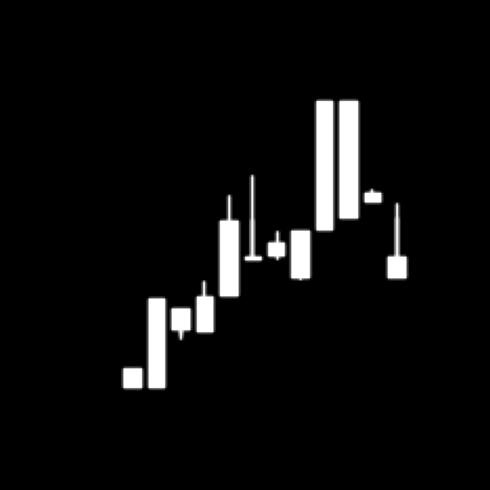


🎉 쿼리 준비 완료!


In [97]:
print("="*80)
print("📋 미국 주식/지수 검색 (yfinance)")
print("="*80)

# 동적 입력 받기 ⭐
query_ticker = input("\n종목 코드 입력 (미국 주식/지수만, 예: NVDA, SPY): ").strip().upper()
query_date_input = input("기준 날짜 입력 (YYYY-MM-DD, 예: 2024-12-01): ").strip()

print(f"\n선택한 종목: {query_ticker}")
print(f"입력한 날짜: {query_date_input}")

# 1. 미국 주식 검증 + 섹터 정보 가져오기 ⭐
print(f"\n🔍 미국 주식 여부 확인 중...")
ticker_obj = yf.Ticker(query_ticker)
info = ticker_obj.info

if not info or len(info) < 5:
    print(f"\n❌ {query_ticker}의 정보를 가져올 수 없습니다.")
    raise ValueError(f"Invalid ticker: {query_ticker}")

exchange = info.get('exchange', 'Unknown')

if exchange not in US_EXCHANGES:
    print(f"\n❌ {query_ticker}는 미국 주식이 아니거나 거래소 정보를 찾을 수 없습니다.")
    print(f"   거래소: {exchange}")
    print(f"\n허용 거래소: {US_EXCHANGES}")
    raise ValueError(f"Invalid ticker: {query_ticker}")

# 섹터 정보 가져오기 ⭐
query_sector = info.get('sector', 'Unknown')

print(f"✅ {query_ticker}는 미국 주식입니다!")
print(f"   거래소: {exchange}")
print(f"   섹터: {query_sector}")

# 2. yfinance에서 데이터 다운로드 (기준 날짜 이전 12주) ⭐
print(f"\n📥 yfinance에서 데이터 다운로드 중...")
print(f"   기준 날짜: {query_date_input}")
print(f"   요청 범위: {query_date_input} 이전 약 12주 (3개월)")

try:
    # 기준 날짜 이전 12주 (안전하게 3개월치 다운로드)
    end_date = pd.to_datetime(query_date_input)
    start_date = end_date - timedelta(weeks=20)  # 여유있게 20주

    data = yf.download(
        query_ticker,
        start=start_date.strftime('%Y-%m-%d'),
        end=end_date.strftime('%Y-%m-%d'),
        interval='1wk',
        progress=False,
        auto_adjust=True
    )

    if data.empty:
        raise ValueError("데이터가 없습니다")

    # OHLC만 추출
    ohlc_data = data[['Open', 'High', 'Low', 'Close']].copy()

    # 멀티인덱스 제거
    if isinstance(ohlc_data.columns, pd.MultiIndex):
        ohlc_data.columns = ['Open', 'High', 'Low', 'Close']

    # 마지막 12주만 선택
    last_12_weeks = ohlc_data.tail(12)

    if len(last_12_weeks) < 12:
        print(f"\n⚠️ 데이터가 부족합니다 (현재: {len(last_12_weeks)}주, 필요: 12주)")
        print(f"   사용 가능한 데이터: {len(ohlc_data)}주")
        raise ValueError("12주 데이터 부족")

    print(f"\n✅ 다운로드 완료!")
    print(f"   전체 주봉 수: {len(ohlc_data)}주")
    print(f"   사용할 12주: {last_12_weeks.index[0].strftime('%Y-%m-%d')} ~ {last_12_weeks.index[-1].strftime('%Y-%m-%d')}")

except Exception as e:
    print(f"\n❌ yfinance 다운로드 실패: {e}")
    raise

# 3. MinMaxScaler 정규화 (노트북 01 전처리 방식) ⭐
print(f"\n🔄 MinMaxScaler 정규화 중 (노트북 01 전처리 방식)...")
scaler = MinMaxScaler()
normalized_ohlc = scaler.fit_transform(last_12_weeks.values)

print(f"✅ 정규화 완료: {normalized_ohlc.shape}")
print(f"   범위: {normalized_ohlc.min():.3f} ~ {normalized_ohlc.max():.3f}")

# 4. 이미지 생성 (노트북 01 전처리 방식) ⭐
print(f"\n🎨 이미지 생성 중 (노트북 01 전처리 방식: mplfinance + 대비 1.5배)...")
query_img = ohlc_to_grayscale_image(normalized_ohlc)

if query_img is None:
    raise ValueError("이미지 생성 실패")

print(f"✅ 이미지 생성 완료: {query_img.shape}")

# 쿼리 이미지 시각화
plt.figure(figsize=(5, 5))
plt.imshow(query_img, cmap='gray', aspect='auto')
plt.title(f'Query: {query_ticker} ({last_12_weeks.index[-1].strftime("%Y-%m-%d")})', fontsize=14, fontweight='bold')
plt.axis('off')
plt.tight_layout()
plt.show()

print("\n" + "="*80)
print("🎉 쿼리 준비 완료!")
print("="*80)

## 10. 쿼리 임베딩 추출

쿼리 이미지를 모델에 통과시켜 512차원 임베딩 벡터를 추출한다. 이 벡터가 전체 47,923개 패턴 데이터베이스와 비교할 검색 키가 된다.

In [98]:
print("\n" + "="*80)
print("🔥 쿼리 임베딩 추출")
print("="*80)

# 임베딩 추출
with torch.no_grad():
    query_img_tensor = torch.FloatTensor(query_img).unsqueeze(0).unsqueeze(0).to(device) / 255.0
    query_embedding = model(query_img_tensor).squeeze(0).cpu().numpy()

print(f"✅ 임베딩 추출 완료: {query_embedding.shape}")

# 메모리 정리
torch.cuda.empty_cache()
gc.collect()

print("\n" + "="*80)
print("🎉 쿼리 임베딩 준비 완료!")
print("="*80)


🔥 쿼리 임베딩 추출
✅ 임베딩 추출 완료: (512,)

🎉 쿼리 임베딩 준비 완료!


## 11. Top-3 탐색 (본인 제외)

Top-100 후보에서 L2 거리 기준으로 쿼리 본인과 중복 종목을 제외하고 Top-3를 선택하는 함수를 정의한다. 같은 종목의 다른 시기 패턴도 본인(2주 이내)이 아니면 검색 결과에 포함될 수 있으며, 종목당 하나만 선택해 다양성을 보장한다.

In [99]:
def get_top3_diverse_exclude_self(query_embedding, query_ticker, query_date, all_embeddings, metadata, k=100):
    """
    L2 Distance 기반 + 종목 중복 제거 + 쿼리 본인 제외 ⭐

    Args:
        query_embedding: 쿼리 이미지의 512차원 임베딩 (L2 normalized)
        query_ticker: 쿼리 종목 코드
        query_date: 쿼리 기준 날짜 (YYYY-MM-DD)
        all_embeddings: 전체 패턴의 임베딩 (N×512, L2 normalized)
        metadata: 패턴 메타데이터
        k: 후보 개수 (기본 100개)

    Returns:
        top3: 상위 3개 패턴 (종목 중복 제거 + 본인 제외됨)
    """
    # 1. L2 Distance 계산 (작을수록 유사)
    distances = np.linalg.norm(all_embeddings - query_embedding, axis=1)

    # 2. Top-K 후보 선택 (거리 작은 순)
    top_k_indices = np.argsort(distances)[:k]  # 오름차순
    top_k_distances = distances[top_k_indices]

    # 3. 종목 중복 제거 + 본인 제외 (가장 유사한 것만) ⭐
    selected = []
    seen_tickers = set()
    query_date_dt = pd.to_datetime(query_date)

    for i in range(k):
        idx = top_k_indices[i]
        ticker = metadata.loc[idx, 'ticker']
        start_date = pd.to_datetime(metadata.loc[idx, 'start_date'])

        # 본인 제외 (같은 종목 + 비슷한 날짜) ⭐
        if ticker == query_ticker:
            date_diff_days = abs((start_date - query_date_dt).days)
            if date_diff_days < 14:  # 2주 이내는 본인으로 간주
                continue

        # 이미 선택된 종목은 스킵
        if ticker in seen_tickers:
            continue

        # 선택
        distance = top_k_distances[i]

        selected.append({
            'idx': idx,
            'ticker': ticker,
            'pattern_id': metadata.loc[idx, 'pattern_id'],
            'date': metadata.loc[idx, 'start_date'],
            'distance': distance,  # L2 distance (작을수록 유사)
            'sector': metadata.loc[idx, 'sector'],
            'return_3m': metadata.loc[idx, 'return_3m'],
            'return_6m': metadata.loc[idx, 'return_6m'],
            'return_1y': metadata.loc[idx, 'return_1y']
        })

        seen_tickers.add(ticker)

        # Top 3 완성
        if len(selected) == 3:
            break

    return selected

print("✅ Top-3 탐색 알고리즘 정의 완료 (L2 Distance + 본인 제외)")

✅ Top-3 탐색 알고리즘 정의 완료 (L2 Distance + 본인 제외)


## 12. Top-3 탐색 실행

Top-3 탐색 함수를 실행하고 각 결과의 종목, 날짜, 섹터, L2 거리, 이후 수익률을 출력한다. 결과가 본인 종목과 중복되지 않고 3개 서로 다른 종목임을 확인한다.

In [100]:
print("\n" + "="*80)
print("🔍 Top-3 유사 패턴 탐색 중... (L2 Distance + 본인 제외)")
print("="*80)

# Top-3 탐색 (본인 제외) ⭐
top3 = get_top3_diverse_exclude_self(
    query_embedding=query_embedding,
    query_ticker=query_ticker,
    query_date=last_12_weeks.index[-1].strftime('%Y-%m-%d'),
    all_embeddings=embeddings,
    metadata=metadata,
    k=100
)

print("\n✅ Top-3 탐색 완료!")
print("\n" + "="*80)
print("📊 검색 결과")
print("="*80)

for rank, item in enumerate(top3, 1):
    print(f"\nTop {rank}:")
    print(f"  종목: {item['ticker']}")
    print(f"  날짜: {item['date']}")
    print(f"  섹터: {item['sector']}")
    print(f"  거리 (L2): {item['distance']:.4f}")
    print(f"  이후 수익률:")
    print(f"    - 3개월: {item['return_3m']:+6.2f}%")
    print(f"    - 6개월: {item['return_6m']:+6.2f}%")
    print(f"    - 12개월: {item['return_1y']:+6.2f}%")

print("\n" + "="*80)


🔍 Top-3 유사 패턴 탐색 중... (L2 Distance + 본인 제외)

✅ Top-3 탐색 완료!

📊 검색 결과

Top 1:
  종목: UBER
  날짜: 2020-11-11
  섹터: Technology
  거리 (L2): 0.3757
  이후 수익률:
    - 3개월:  +1.24%
    - 6개월: -17.96%
    - 12개월: -31.62%

Top 2:
  종목: BKR
  날짜: 2020-06-24
  섹터: Energy
  거리 (L2): 0.4341
  이후 수익률:
    - 3개월: +54.18%
    - 6개월: +68.96%
    - 12개월: +71.41%

Top 3:
  종목: UPS
  날짜: 2025-04-30
  섹터: Industrials
  거리 (L2): 0.4797
  이후 수익률:
    - 3개월: -15.33%
    - 6개월:   +nan%
    - 12개월:   +nan%



## 13. 컬러 캔들스틱 생성 함수

원본 OHLC CSV에서 해당 기간 데이터를 읽어 컬러 캔들스틱 이미지를 생성한다. 학습에는 흑백 이미지를 사용했지만 결과 시각화에는 상승(녹색)/하락(빨강) 컬러로 표시해 직관적인 패턴 확인이 가능하도록 한다.

In [101]:
def generate_color_candlestick(ticker, start_date, end_date, raw_data_path):
    """
    원본 OHLC 데이터에서 컬러 캔들스틱 차트 생성

    Args:
        ticker: 종목 코드
        start_date: 시작 날짜 (YYYY-MM-DD)
        end_date: 종료 날짜 (YYYY-MM-DD)
        raw_data_path: raw 폴더 경로

    Returns:
        img_array: RGB 이미지 배열 (224x224x3)
    """
    # 1. raw CSV 로드
    csv_path = f"{raw_data_path}/{ticker}.csv"
    df = pd.read_csv(csv_path, index_col=0, parse_dates=True)

    # 2. 날짜 범위로 12주 추출
    df_period = df.loc[start_date:end_date]

    # 3. mplfinance로 컬러 캔들스틱 생성
    mc = mpf.make_marketcolors(
        up='#26a69a',      # 녹색 (상승)
        down='#ef5350',    # 빨간색 (하락)
        edge='inherit',
        wick='inherit',
        volume='in'
    )

    s = mpf.make_mpf_style(
        marketcolors=mc,
        gridstyle='',
        facecolor='white',
        figcolor='white'
    )

    # 4. 임시 파일에 저장
    buf = io.BytesIO()
    mpf.plot(
        df_period,
        type='candle',
        style=s,
        savefig=dict(fname=buf, dpi=100, bbox_inches='tight', pad_inches=0),
        figsize=(2.24, 2.24),
        axisoff=True
    )

    # 5. 이미지 로드 및 리사이즈
    buf.seek(0)
    img = Image.open(buf)
    img_resized = img.resize((224, 224), Image.Resampling.LANCZOS)
    img_array = np.array(img_resized)

    # RGB 변환 (RGBA인 경우)
    if img_array.shape[-1] == 4:
        img_array = img_array[:, :, :3]

    buf.close()

    return img_array

print("✅ 컬러 캔들스틱 생성 함수 정의 완료")

✅ 컬러 캔들스틱 생성 함수 정의 완료


## 14. 5×3 행렬 시각화

5×3 행렬 형식으로 쿼리와 Top-3 결과를 컬러 캔들스틱으로 나란히 시각화한다. 행: 순위 / 기본 정보 / 차트 이미지 / L2 거리 / 이후 수익률. 검은 배경에 흰색 텍스트로 차트를 강조한다.

In [102]:
def display_top3_results(query_img, query_ticker, query_date, query_sector, query_ohlc, top3, metadata, raw_data_path):
    """
    5×3 행렬 시각화 (컬러 캔들스틱 출력) ⭐

    Row 1: 순위
    Row 2: 기본 정보
    Row 3: 유사 차트 (컬러!)
    Row 4: 거리 (L2 Distance)
    Row 5: 이후 흐름

    Args:
        query_img: 쿼리 이미지 (grayscale) - 사용 안함
        query_ticker: 쿼리 종목 코드
        query_date: 쿼리 기준 날짜
        query_sector: 쿼리 종목 섹터
        query_ohlc: 쿼리 원본 OHLC 데이터 (12주) ⭐
        top3: Top-3 검색 결과
        metadata: 메타데이터
        raw_data_path: raw 폴더 경로 (원본 OHLC)
    """
    fig = plt.figure(figsize=(20, 10), facecolor='black')  # 전체 배경 검은색
    gs = GridSpec(5, 4, figure=fig, hspace=0.6, wspace=0.4,
                  height_ratios=[0.8, 1, 3, 1.2, 1.5])

    # 쿼리 이미지 (왼쪽) - 컬러 캔들스틱으로 변경 ⭐
    ax_query = fig.add_subplot(gs[1:3, 0], facecolor='black')

    # 쿼리 OHLC로 컬러 캔들스틱 생성 ⭐
    mc = mpf.make_marketcolors(
        up='#26a69a',      # 녹색 (상승)
        down='#ef5350',    # 빨간색 (하락)
        edge='inherit',
        wick='inherit',
        volume='in'
    )
    s = mpf.make_mpf_style(
        marketcolors=mc,
        gridstyle='',
        facecolor='white',
        figcolor='white'
    )

    buf = io.BytesIO()
    mpf.plot(
        query_ohlc,
        type='candle',
        style=s,
        savefig=dict(fname=buf, dpi=100, bbox_inches='tight', pad_inches=0),
        figsize=(2.24, 2.24),
        axisoff=True
    )

    buf.seek(0)
    query_color_chart = Image.open(buf)
    query_color_chart_resized = query_color_chart.resize((224, 224), Image.Resampling.LANCZOS)
    query_color_array = np.array(query_color_chart_resized)

    if query_color_array.shape[-1] == 4:
        query_color_array = query_color_array[:, :, :3]

    buf.close()

    ax_query.imshow(query_color_array, aspect='auto')
    ax_query.set_title(f'Query\n{query_ticker} ({query_date})',
                       fontsize=14, fontweight='bold', color='white')
    ax_query.axis('off')

    # Top-3 (오른쪽 3열)
    for col, item in enumerate(top3, 1):
        # Row 0: 순위
        ax_rank = fig.add_subplot(gs[0, col], facecolor='black')
        ax_rank.text(0.5, 0.5, f'Top {col}', ha='center', va='center',
                     fontsize=18, fontweight='bold', color='black',
                     bbox=dict(boxstyle='round', facecolor='gold' if col==1 else 'silver' if col==2 else 'lightcoral', alpha=0.9))
        ax_rank.axis('off')

        # Row 1: 기본 정보 (흰색 텍스트 + 검은 배경) ⭐
        ax_info = fig.add_subplot(gs[1, col], facecolor='black')
        info_text = f"{item['ticker']}\n{item['date']}\n{item['sector']}"
        ax_info.text(0.5, 0.5, info_text, ha='center', va='center',
                     fontsize=12, wrap=True, color='white', fontweight='bold',
                     bbox=dict(boxstyle='round', facecolor='black', alpha=0.8, edgecolor='white', linewidth=2))
        ax_info.axis('off')

        # Row 2: 차트 이미지 (컬러!) ⭐
        ax_chart = fig.add_subplot(gs[2, col], facecolor='black')

        # 원본 OHLC에서 컬러 캔들스틱 생성
        ticker = item['ticker']
        start_date = metadata.loc[item['idx'], 'start_date']
        end_date = metadata.loc[item['idx'], 'end_date']

        color_chart = generate_color_candlestick(ticker, start_date, end_date, raw_data_path)
        ax_chart.imshow(color_chart, aspect='auto')
        ax_chart.axis('off')

        # Row 3: 거리 (L2 Distance)
        ax_sim = fig.add_subplot(gs[3, col], facecolor='black')
        sim_text = f"L2 Distance: {item['distance']:.4f}"
        ax_sim.text(0.5, 0.5, sim_text, ha='center', va='center',
                    fontsize=12, fontweight='bold', color='black',
                    bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.9, edgecolor='green', linewidth=2))
        ax_sim.axis('off')

        # Row 4: 이후 흐름 (흰색 텍스트) ⭐
        ax_return = fig.add_subplot(gs[4, col], facecolor='black')
        return_text = f"3M: {item['return_3m']:+6.2f}%\n6M: {item['return_6m']:+6.2f}%\n12M: {item['return_1y']:+6.2f}%"
        ax_return.text(0.5, 0.5, return_text, ha='center', va='center',
                       fontsize=12, fontweight='bold', color='white',
                       bbox=dict(boxstyle='round', facecolor='#1e1e1e', alpha=0.9, edgecolor='white', linewidth=2))
        ax_return.axis('off')

    # 쿼리 정보 (왼쪽 하단) - 섹터 정보 추가 ⭐
    ax_query_info = fig.add_subplot(gs[3:5, 0], facecolor='black')
    query_info_text = f"yfinance Query\n\nTicker: {query_ticker}\nDate: {query_date}\nSector: {query_sector}\n\nSearch:\n- L2 Distance\n- Top-100 candidates\n- Exclude self"
    ax_query_info.text(0.5, 0.5, query_info_text, ha='center', va='center',
                       fontsize=11, fontweight='bold', color='white',
                       bbox=dict(boxstyle='round', facecolor='#1e1e1e', alpha=0.9, edgecolor='cyan', linewidth=2))
    ax_query_info.axis('off')

    plt.suptitle('Top-3 Similar Pattern Search Results (yfinance + L2 Distance)',
                 fontsize=20, fontweight='bold', y=0.98, color='white')
    plt.tight_layout()
    plt.show()

print("✅ 시각화 함수 정의 완료 (쿼리도 컬러 캔들스틱 + L2 Distance + 흰색 텍스트)")

✅ 시각화 함수 정의 완료 (쿼리도 컬러 캔들스틱 + L2 Distance + 흰색 텍스트)



🖼️ 5×3 행렬 시각화 (컬러 캔들스틱)


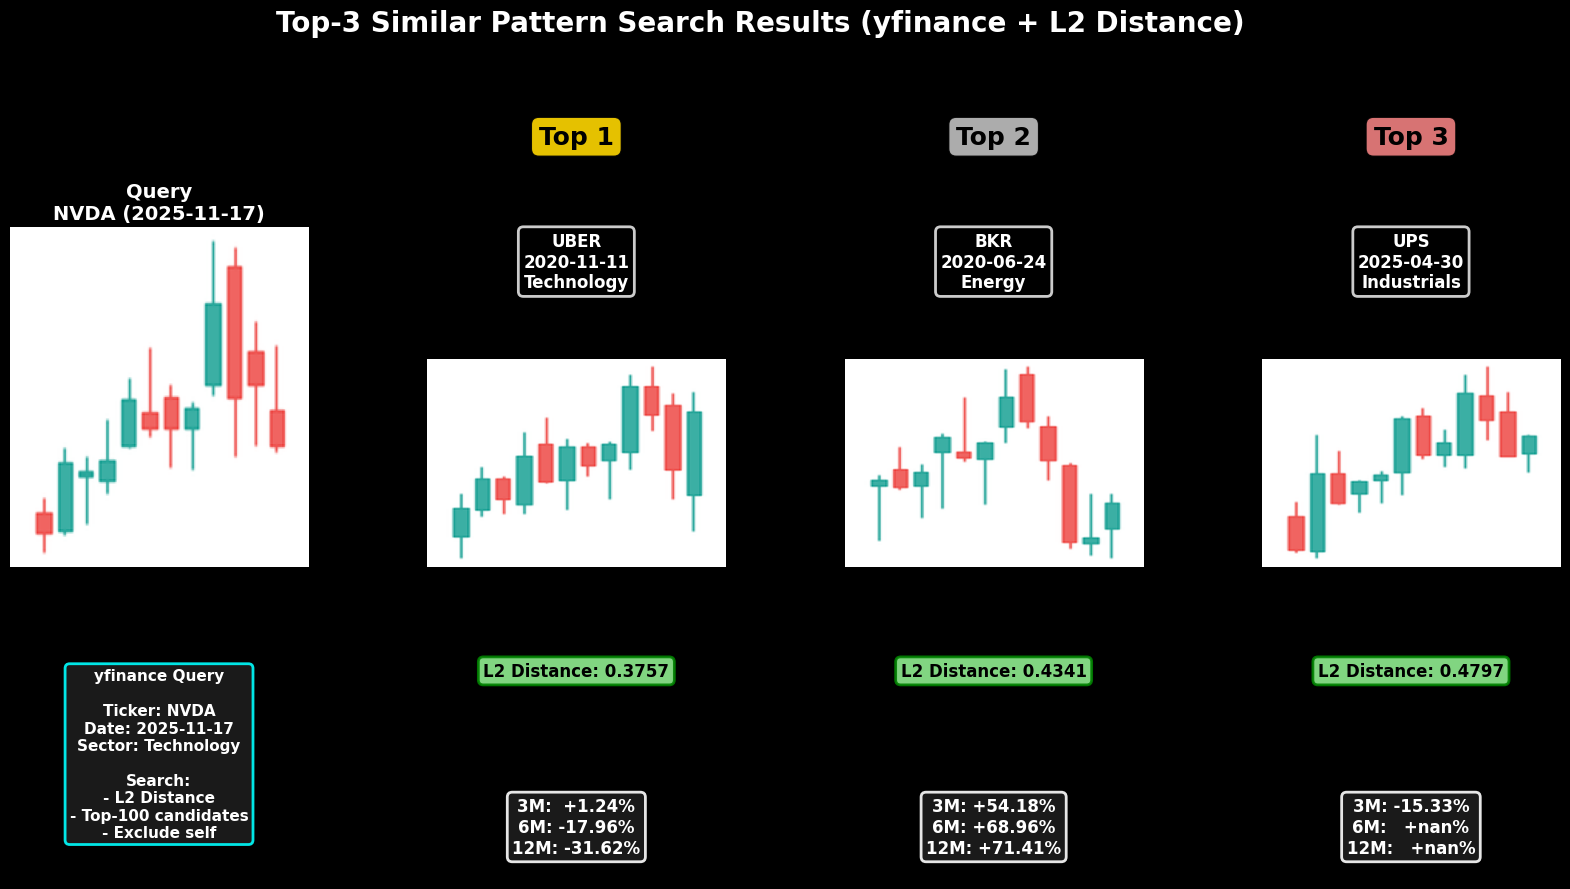


✅ 시각화 완료! (원본 OHLC → 컬러 출력)


In [103]:
# 결과 시각화 (컬러 캔들스틱) ⭐
print("\n" + "="*80)
print("🖼️ 5×3 행렬 시각화 (컬러 캔들스틱)")
print("="*80)

RAW_DATA_PATH = f'{DATA_PATH}/raw'
display_top3_results(
    query_img=query_img,
    query_ticker=query_ticker,
    query_date=last_12_weeks.index[-1].strftime('%Y-%m-%d'),
    query_sector=query_sector,
    query_ohlc=last_12_weeks,
    top3=top3,
    metadata=metadata,
    raw_data_path=RAW_DATA_PATH
)

print("\n✅ 시각화 완료! (원본 OHLC → 컬러 출력)")

In [104]:
print("\n" + "="*80)
print("📊 검색 통계")
print("="*80)

# 거리 (L2 Distance: 0 이상, 0에 가까울수록 유사)
distances = [item['distance'] for item in top3]
print(f"\n[L2 Distance (0 이상, 0=완전 동일)]")
print(f"  Top 1: {distances[0]:.4f}")
print(f"  Top 2: {distances[1]:.4f}")
print(f"  Top 3: {distances[2]:.4f}")
print(f"  평균: {np.mean(distances):.4f}")

# 이후 수익률
returns_3m = [item['return_3m'] for item in top3]
returns_6m = [item['return_6m'] for item in top3]
returns_1y = [item['return_1y'] for item in top3]

print(f"\n[이후 평균 수익률]")
print(f"  3개월: {np.mean(returns_3m):+6.2f}%")
print(f"  6개월: {np.mean(returns_6m):+6.2f}%")
print(f"  12개월: {np.mean(returns_1y):+6.2f}%")

# 종목 다양성
tickers = [item['ticker'] for item in top3]
unique_tickers = len(set(tickers))
print(f"\n[종목 다양성]")
print(f"  고유 종목 수: {unique_tickers}개 / 3개")
if unique_tickers == 3:
    print(f"  ✅ 완벽한 다양성! (중복 없음)")
elif unique_tickers == 2:
    print(f"  ⚠️ 중복 1개")
else:
    print(f"  ❌ 모두 같은 종목")

# 본인 제외 확인
has_self = any(item['ticker'] == query_ticker for item in top3)
print(f"\n[본인 제외 확인]")
if has_self:
    print(f"  ⚠️ 쿼리 종목({query_ticker})이 결과에 포함됨")
else:
    print(f"  ✅ 쿼리 종목({query_ticker}) 제외 완료!")

print("\n" + "="*80)
print("🎉 yfinance 실시간 검색 완료!")
print("="*80)


📊 검색 통계

[L2 Distance (0 이상, 0=완전 동일)]
  Top 1: 0.3757
  Top 2: 0.4341
  Top 3: 0.4797
  평균: 0.4298

[이후 평균 수익률]
  3개월: +13.36%
  6개월:   +nan%
  12개월:   +nan%

[종목 다양성]
  고유 종목 수: 3개 / 3개
  ✅ 완벽한 다양성! (중복 없음)

[본인 제외 확인]
  ✅ 쿼리 종목(NVDA) 제외 완료!

🎉 yfinance 실시간 검색 완료!
